In [3]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h2o
from h2o.automl import H2OAutoML
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Cell 2: Load and preprocess dataa

df = pd.read_csv("J16WL.csv")

# Convert columns to datetime
df['LBR_WORK_DATE'] = pd.to_datetime(df['LBR_WORK_DATE'])
df['ACTU_START_TS'] = pd.to_datetime(df['ACTU_START_TS'])
df['ACTU_END_TS'] = pd.to_datetime(df['ACTU_END_TS'])

print(df.head())

   EMP_ID LBR_WORK_DATE LBR_CHRG_NO       ACTU_START_TS         ACTU_END_TS  \
0  119915    2024-06-08      BQ5853 2024-06-08 09:53:03 2024-06-08 09:59:00   
1  119915    2024-06-11      BQ5853 2024-06-10 20:40:00 2024-06-11 04:28:00   
2  119915    2024-06-11      BQ5853 2024-06-10 22:21:00 2024-06-11 02:00:00   
3  119915    2024-06-11      BQ5853 2024-06-11 02:31:00 2024-06-11 03:15:00   
4  119915    2024-06-11      BQ5853 2024-06-11 03:51:00 2024-06-11 04:29:00   

   SHIFT_CD  ELAPS_ACTY_TIME  QTY_CMPLTD WO_OPR_NO  WC_POOL WC_STN  \
0         3             0.05          40      020        88   J16W   
1         3             4.61          10      020        88   J16W   
2         3             1.83          10      020        88   J16W   
3         3             0.37          10      020        88   J16W   
4         3             0.32         148      020        88   J16W   

                     ITEM_NO  LBR_STD_TIME  EARNED_HRS  PERF_PCT  
0  18-44737-002                      

In [5]:
# Cell 3: Train/test split

train = df[df['LBR_WORK_DATE'] < "2025-08-01"].copy()
test = df[(df['LBR_WORK_DATE'] >= "2025-08-01") & (df['LBR_WORK_DATE'] < "2025-09-01")].copy()

print(f"Train rows: {train.shape[0]}, Test rows: {test.shape[0]}")

Train rows: 2760, Test rows: 68


In [6]:
# Cell 4: Initialize H2O

h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; OpenJDK 64-Bit Server VM Corretto-21.0.5.11.1 (build 21.0.5+11-LTS, mixed mode, sharing)
  Starting server from C:\Users\PAVSHAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\PAVSHAN\AppData\Local\Temp\tmpmh6_5fx2
  JVM stdout: C:\Users\PAVSHAN\AppData\Local\Temp\tmpmh6_5fx2\h2o_PAVSHAN_started_from_python.out
  JVM stderr: C:\Users\PAVSHAN\AppData\Local\Temp\tmpmh6_5fx2\h2o_PAVSHAN_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,America/New_York
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.7
H2O_cluster_version_age:,5 months and 5 days
H2O_cluster_name:,H2O_from_python_PAVSHAN_e8rjgi
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,15.89 Gb
H2O_cluster_total_cores:,0
H2O_cluster_allowed_cores:,0
H2O_cluster_status:,"locked, healthy"


In [7]:
# Cell 5: Set up features & targets

target_cols = ["EARNED_HRS", "PERF_PCT"]
exclude_cols = ["EMP_ID", "LBR_WORK_DATE", "ACTU_START_TS", "ACTU_END_TS", "EARNED_HRS", "PERF_PCT"]
feature_cols = [col for col in df.columns if col not in exclude_cols]

train_h2o = h2o.H2OFrame(train)
test_h2o = h2o.H2OFrame(test)

result_dict = {}

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [8]:
# Cell 6: Train AutoML on each target and predict

for target in target_cols:
    print(f"\n=== Running H2O AutoML for {target} ===")
    aml = H2OAutoML(max_runtime_secs=120, seed=42)
    aml.train(x=feature_cols, y=target, training_frame=train_h2o)
    
    preds = aml.predict(test_h2o)
    test[f"{target}_PRED"] = preds.as_data_frame().values.flatten()
    result_dict[target] = aml

print("Model training and predictions finished.")


=== Running H2O AutoML for EARNED_HRS ===
AutoML progress: |
13:20:09.163: AutoML: XGBoost is not available; skipping it.
13:20:09.296: _train param, Dropping bad and constant columns: [WC_POOL, WC_STN]

█
13:20:11.868: _train param, Dropping bad and constant columns: [WC_POOL, WC_STN]

███
13:20:17.641: _train param, Dropping unused columns: [WC_POOL, WC_STN]
13:20:17.975: _train param, Dropping bad and constant columns: [WC_POOL, WC_STN]

████
13:20:24.725: _train param, Dropping bad and constant columns: [WC_POOL, WC_STN]

█
13:20:26.429: _train param, Dropping bad and constant columns: [WC_POOL, WC_STN]

█
13:20:28.109: _train param, Dropping bad and constant columns: [WC_POOL, WC_STN]

█
13:20:30.383: _train param, Dropping unused columns: [WC_POOL, WC_STN]
13:20:30.589: _train param, Dropping unused columns: [WC_POOL, WC_STN]
13:20:30.995: _train param, Dropping bad and constant columns: [WC_POOL, WC_STN]

█████
13:20:39.474: _train param, Dropping bad and constant columns: [WC_

c:\Users\PAVSHAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\h2o\job.py:81: UserWarning: Test/Validation dataset column 'LBR_CHRG_NO' has levels not trained on: ["BU6724", "BU6865", "BU7585", "BU7935", "BU7993", "BU8558", "BU8699", "BU8775", "BU8837", "BU9226", ...15 not listed..., "XL7032", "XL7334", "XL7521", "XL7639", "XL7831", "XL9228", "XM2371", "XM2372", "XM2373", "XM2616"]
  warnings.warn(w)
c:\Users\PAVSHAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\h2o\job.py:81: UserWarning: Test/Validation dataset column 'ITEM_NO' has levels not trained on: ["15-29613-000             ", "15-29613-001             ", "15-29614-000             ", "15-29614-001             "]
  warnings.warn(w)
c:\Users\PAVSHAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o


13:22:11.63: AutoML: XGBoost is not available; skipping it.
13:22:11.63: _train param, Dropping bad and constant columns: [WC_POOL, WC_STN]


13:22:11.759: _train param, Dropping bad and constant columns: [WC_POOL, WC_STN]

█
13:22:12.869: _train param, Dropping unused columns: [WC_POOL, WC_STN]
13:22:13.29: _train param, Dropping bad and constant columns: [WC_POOL, WC_STN]

█████
13:22:17.452: _train param, Dropping bad and constant columns: [WC_POOL, WC_STN]
13:22:18.100: _train param, Dropping bad and constant columns: [WC_POOL, WC_STN]
13:22:18.701: _train param, Dropping bad and constant columns: [WC_POOL, WC_STN]

█
13:22:19.687: _train param, Dropping unused columns: [WC_POOL, WC_STN]
13:22:19.880: _train param, Dropping unused columns: [WC_POOL, WC_STN]

█
13:22:20.66: _train param, Dropping bad and constant columns: [WC_POOL, WC_STN]

██████
13:22:26.686: _train param, Dropping bad and constant columns: [WC_POOL, WC_STN]

█
13:22:27.684: _train param, Dropping bad and constan

c:\Users\PAVSHAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\h2o\job.py:81: UserWarning: Test/Validation dataset column 'LBR_CHRG_NO' has levels not trained on: ["BU6724", "BU6865", "BU7585", "BU7935", "BU7993", "BU8558", "BU8699", "BU8775", "BU8837", "BU9226", ...15 not listed..., "XL7032", "XL7334", "XL7521", "XL7639", "XL7831", "XL9228", "XM2371", "XM2372", "XM2373", "XM2616"]
  warnings.warn(w)
c:\Users\PAVSHAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\h2o\job.py:81: UserWarning: Test/Validation dataset column 'ITEM_NO' has levels not trained on: ["15-29613-000             ", "15-29613-001             ", "15-29614-000             ", "15-29614-001             "]
  warnings.warn(w)
c:\Users\PAVSHAN\AppData\Local\Programs\Python\Python313\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o

In [9]:
# Cell 7: Define and run metrics function

def print_metrics(true, pred, name="Metric"):
    mae = mean_absolute_error(true, pred)
    mse = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, pred)
    print(f"\n{name} Metrics:")
    print(f"MAE:  {mae:,.3f}")
    print(f"RMSE: {rmse:,.3f}")
    print(f"R2:   {r2:,.3f}")

for target in target_cols:
    print_metrics(test[target], test[f"{target}_PRED"], name=f"{target} (All)")
    for shift in sorted(test['SHIFT_CD'].unique()):
        test_shift = test[test['SHIFT_CD'] == shift]
        print_metrics(test_shift[target], test_shift[f"{target}_PRED"], name=f"{target} (Shift {shift})")


EARNED_HRS (All) Metrics:
MAE:  0.206
RMSE: 0.423
R2:   0.961

EARNED_HRS (Shift 1) Metrics:
MAE:  0.099
RMSE: 0.145
R2:   0.996

EARNED_HRS (Shift 2) Metrics:
MAE:  0.138
RMSE: 0.201
R2:   0.994

EARNED_HRS (Shift 3) Metrics:
MAE:  0.338
RMSE: 0.636
R2:   0.796

PERF_PCT (All) Metrics:
MAE:  39.907
RMSE: 67.231
R2:   0.609

PERF_PCT (Shift 1) Metrics:
MAE:  59.837
RMSE: 107.758
R2:   0.607

PERF_PCT (Shift 2) Metrics:
MAE:  23.040
RMSE: 26.702
R2:   0.236

PERF_PCT (Shift 3) Metrics:
MAE:  38.263
RMSE: 47.200
R2:   0.627


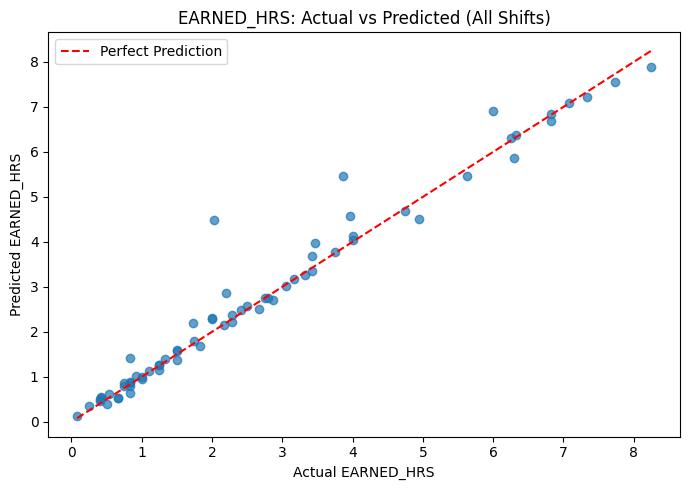

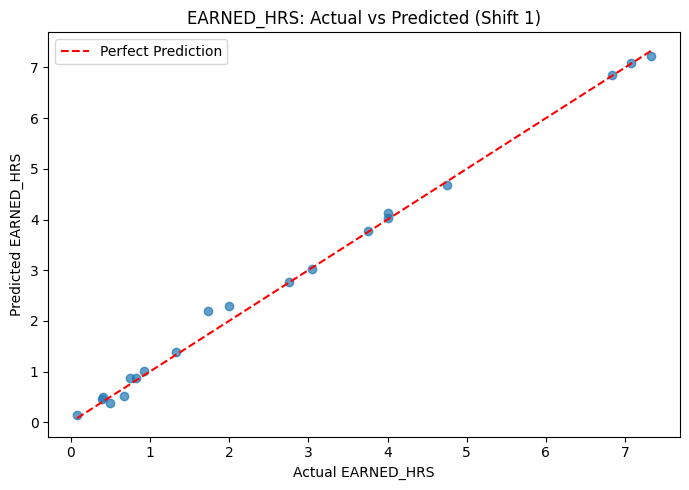

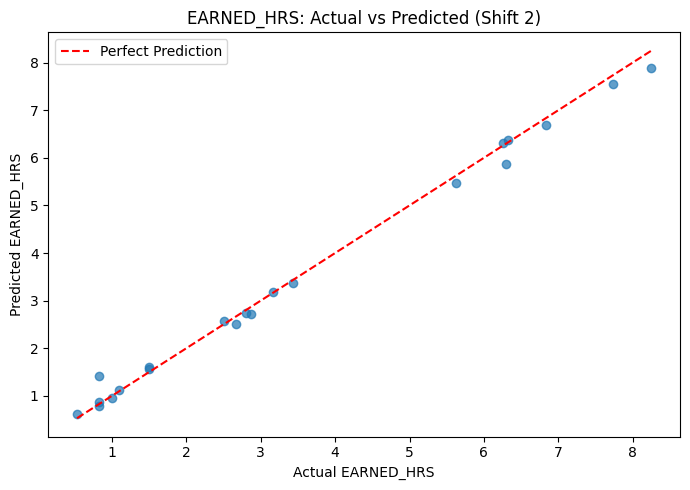

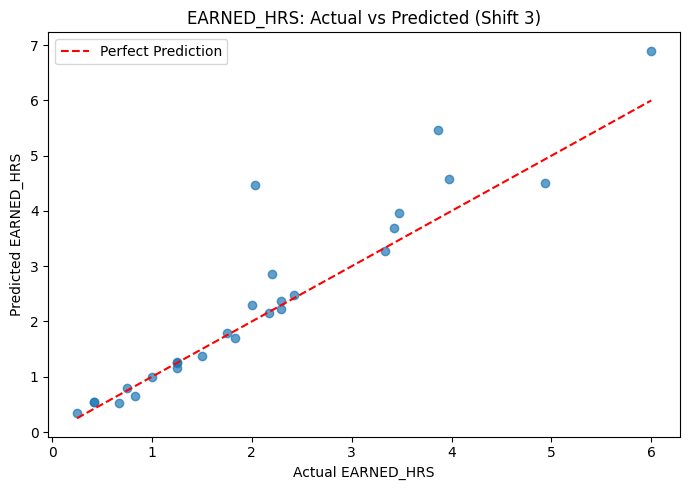

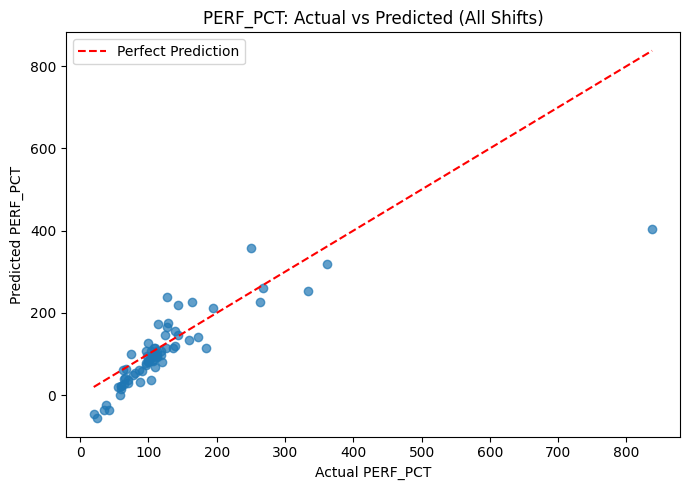

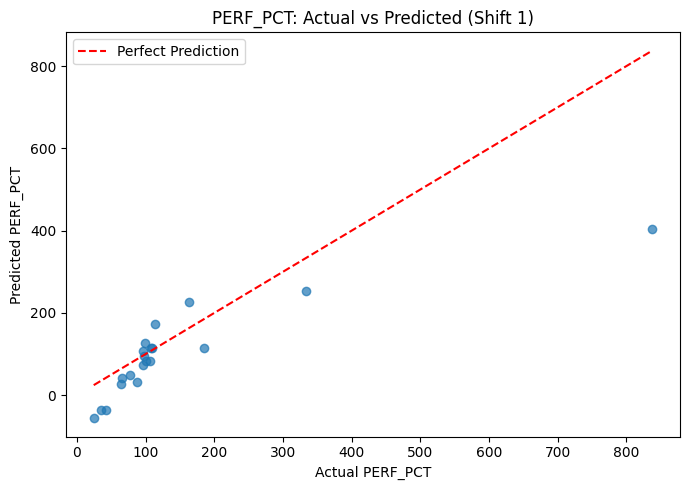

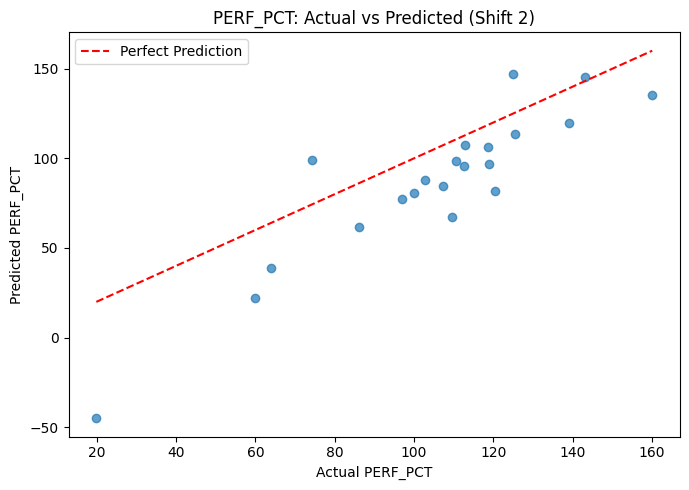

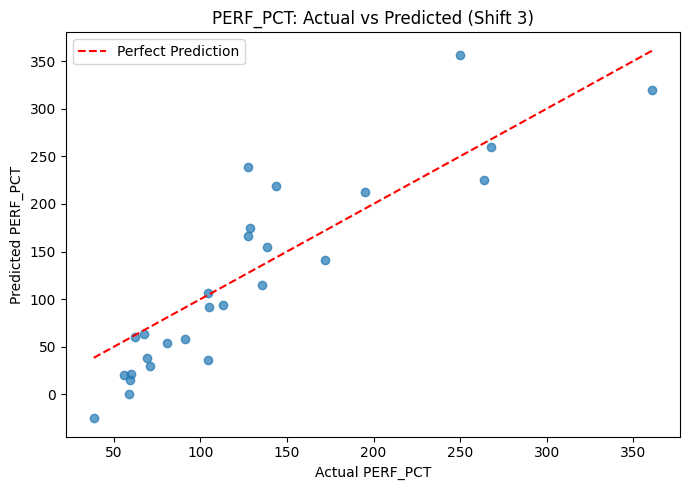

In [10]:
# Cell 8: Plot & save graphs

for target in target_cols:
    # All shifts
    plt.figure(figsize=(7,5))
    plt.title(f"{target}: Actual vs Predicted (All Shifts)")
    plt.scatter(test[target], test[f"{target}_PRED"], alpha=0.7)
    plt.xlabel(f"Actual {target}")
    plt.ylabel(f"Predicted {target}")
    plt.plot([test[target].min(), test[target].max()],
             [test[target].min(), test[target].max()], 'r--', label='Perfect Prediction')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{target}_All_Shifts.png")   
    plt.show()
    plt.close()
    
    # By shift
    for shift in sorted(test['SHIFT_CD'].unique()):
        test_shift = test[test['SHIFT_CD'] == shift]
        plt.figure(figsize=(7,5))
        plt.title(f"{target}: Actual vs Predicted (Shift {shift})")
        plt.scatter(test_shift[target], test_shift[f"{target}_PRED"], alpha=0.7)
        plt.xlabel(f"Actual {target}")
        plt.ylabel(f"Predicted {target}")
        plt.plot([test_shift[target].min(), test_shift[target].max()],
                 [test_shift[target].min(), test_shift[target].max()], 'r--', label='Perfect Prediction')
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"{target}_Shift_{shift}.png")
        plt.show()
        plt.close()

In [11]:
# Cell 10: Save test set with predictions for download
test.to_csv("test_with_predictions.csv", index=False)
print("Test set with predictions saved as 'test_with_predictions.csv'.")

PermissionError: [Errno 13] Permission denied: 'test_with_predictions.csv'

In [ ]:
# Cell 9: Show predicted vs. actual values

print("\nFirst 10 results for EARNED_HRS:")
print(test[['EARNED_HRS', 'EARNED_HRS_PRED']].head(10))

print("\nFirst 10 results for PERF_PCT:")
print(test[['PERF_PCT', 'PERF_PCT_PRED']].head(10))


First 10 results for EARNED_HRS:
      EARNED_HRS  EARNED_HRS_PRED
58          3.42         3.683185
86          2.00         2.104693
105         1.75         1.763929
106         0.08        -0.089583
125         0.40         0.219068
1949        1.73         1.914108
2766        3.75         3.659092
2767        6.25         6.270563
2768        2.17         2.193620
2769        1.25         1.147793

First 10 results for PERF_PCT:
      PERF_PCT  PERF_PCT_PRED
58       55.88      19.944609
86       69.44      37.853325
105      59.93      21.352886
106     114.29     172.270254
125      42.11     -36.847813
1949     98.86     126.935969
2766     77.32      49.036818
2767    102.80      87.713661
2768    138.22     155.162555
2769    143.68     219.325368


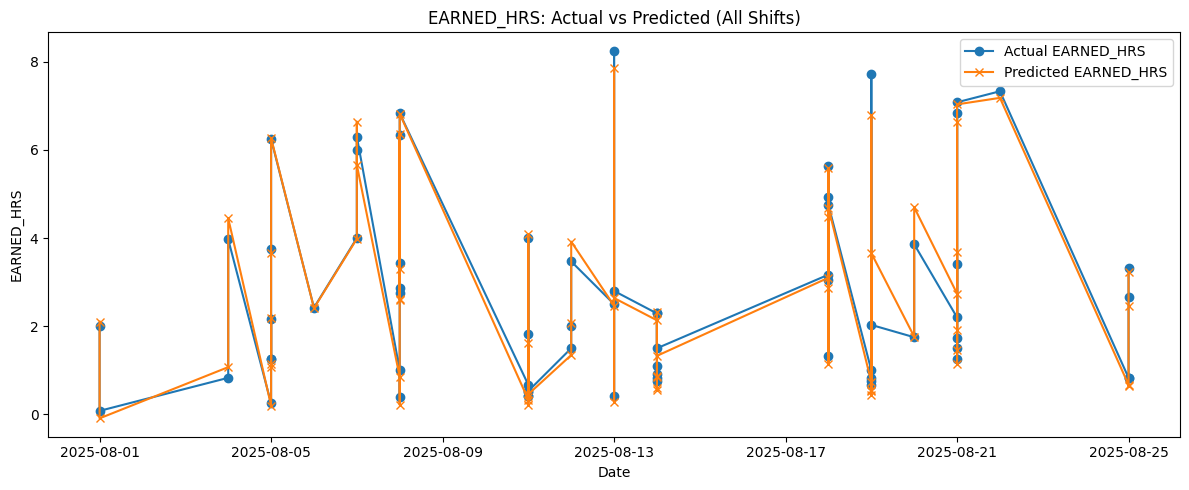

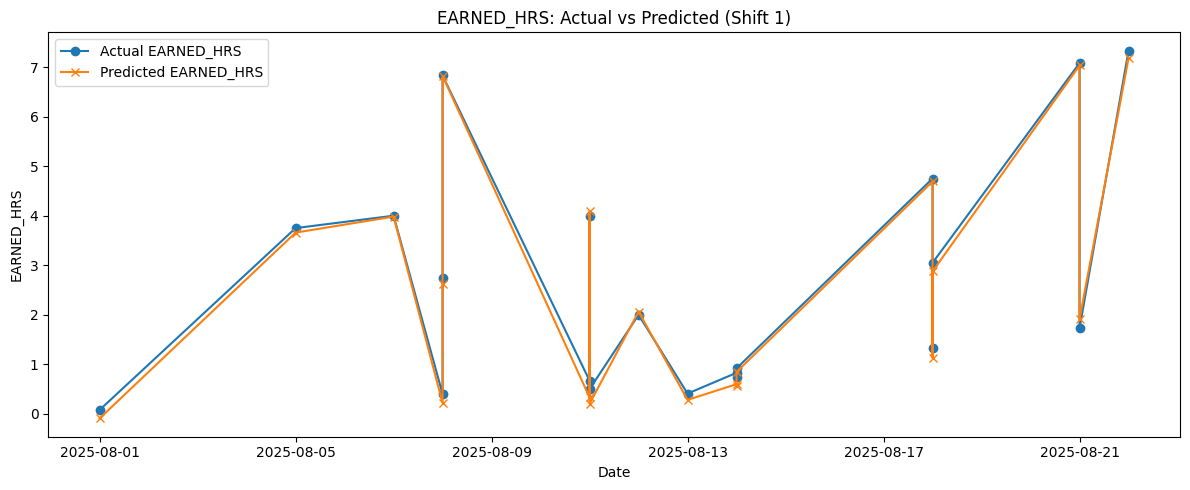

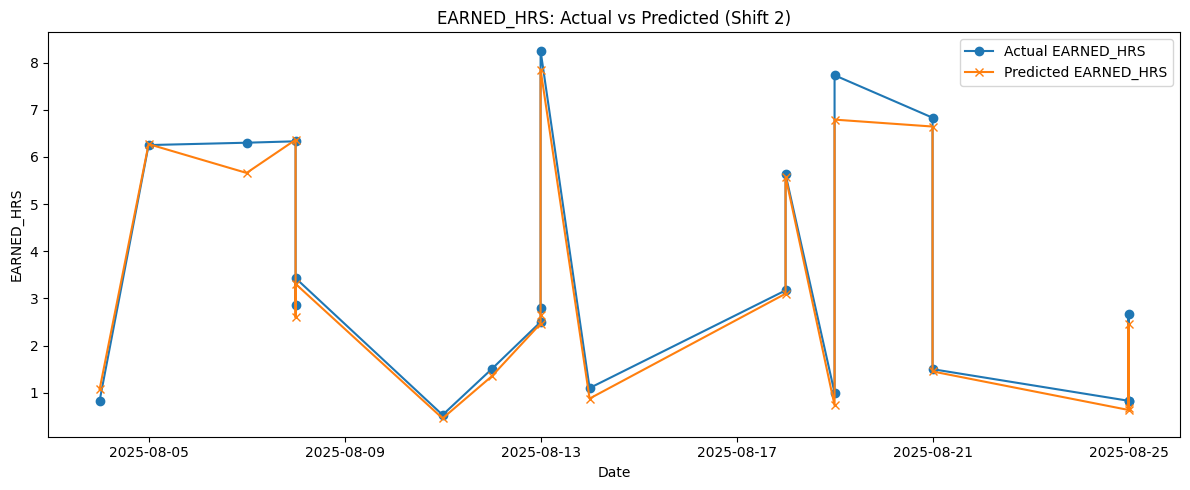

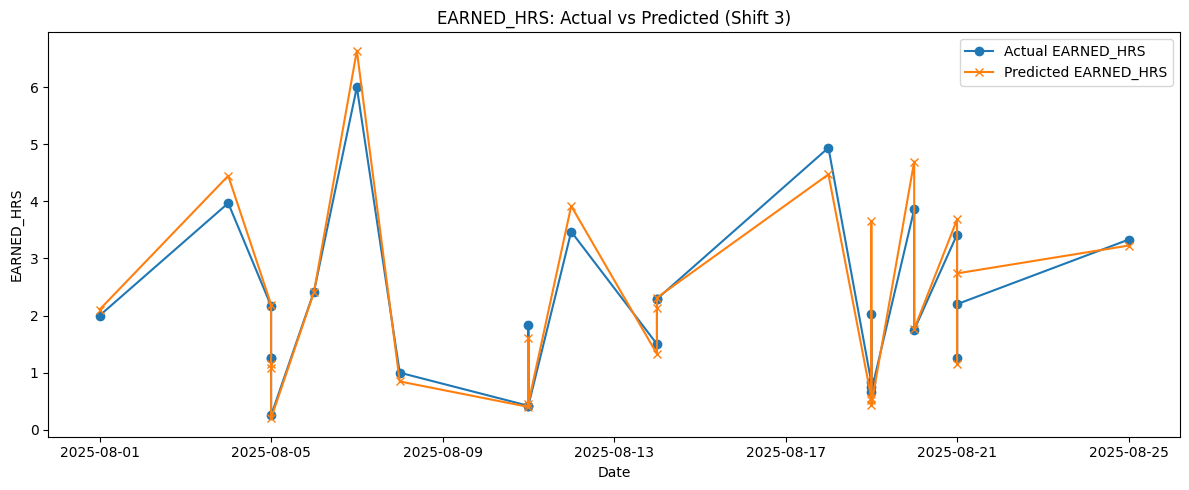

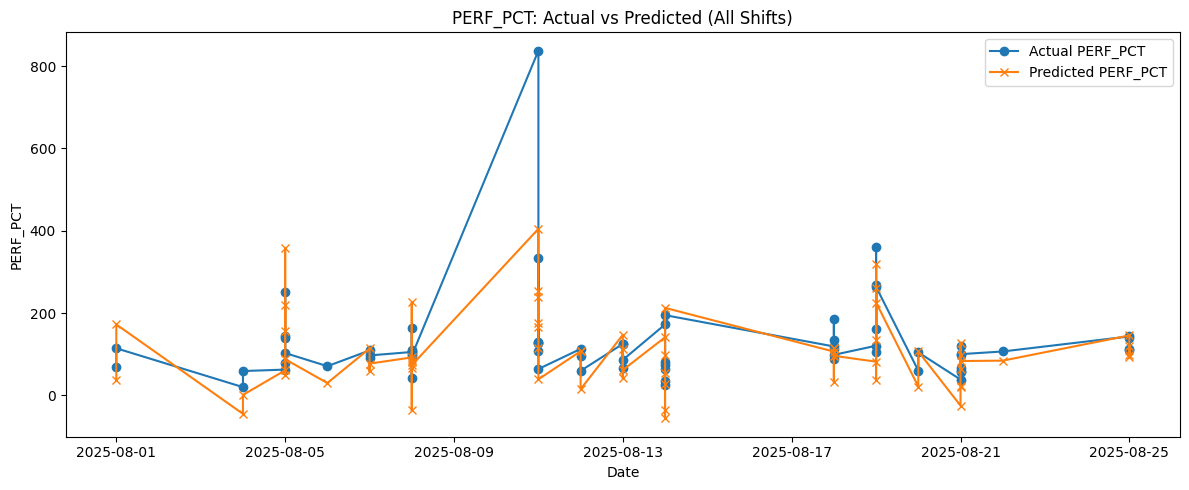

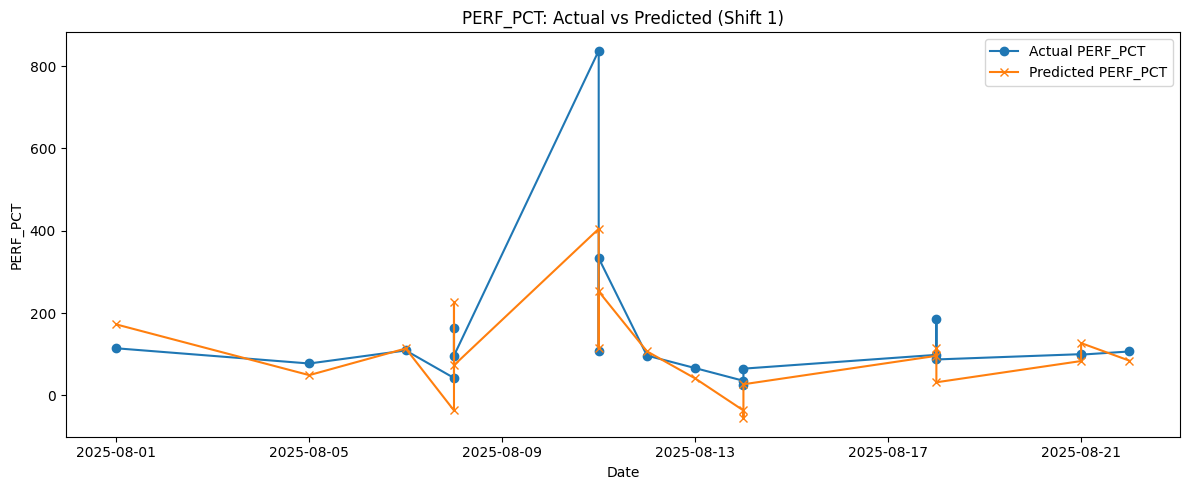

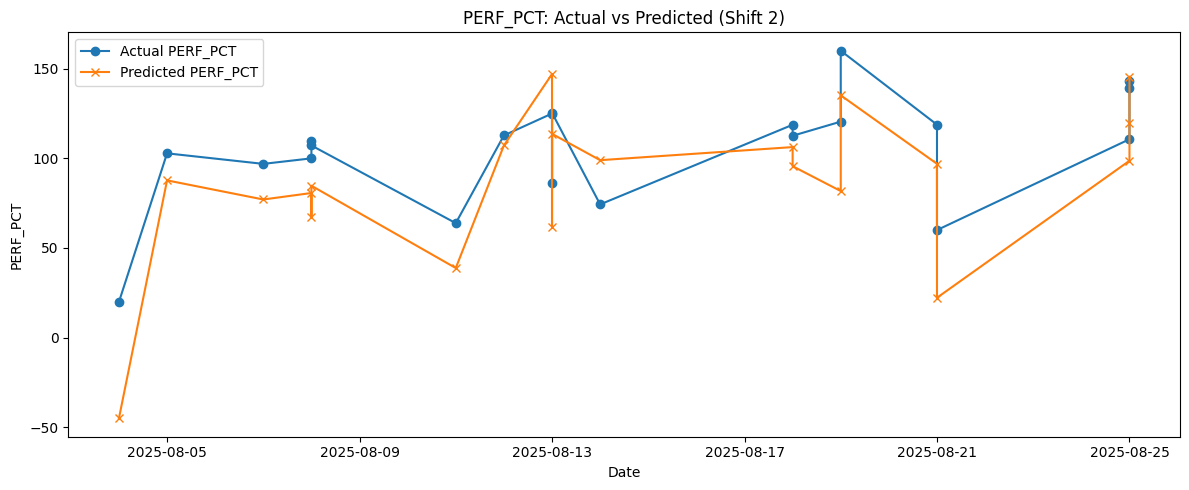

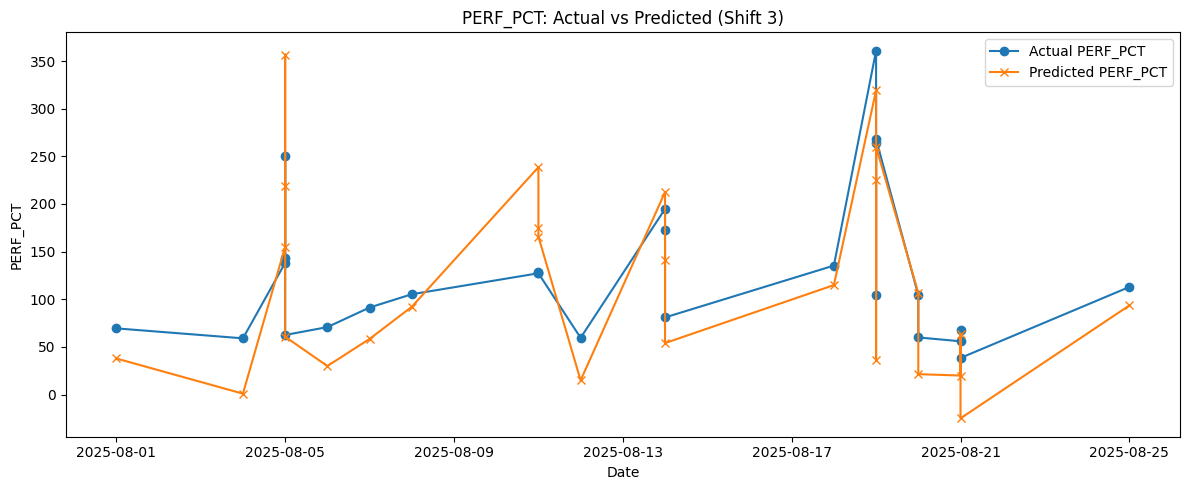

In [ ]:
# --- Line Graph: EARNED_HRS (All Shifts) ---
test_sorted = test.sort_values('LBR_WORK_DATE')
plt.figure(figsize=(12, 5))
plt.plot(test_sorted['LBR_WORK_DATE'], test_sorted['EARNED_HRS'], label='Actual EARNED_HRS', marker='o')
plt.plot(test_sorted['LBR_WORK_DATE'], test_sorted['EARNED_HRS_PRED'], label='Predicted EARNED_HRS', marker='x')
plt.xlabel('Date')
plt.ylabel('EARNED_HRS')
plt.title('EARNED_HRS: Actual vs Predicted (All Shifts)')
plt.legend()
plt.tight_layout()
plt.savefig('Line_EARNED_HRS_Line_All_Shifts.png')
plt.show()
plt.close()

# --- Line Graph: EARNED_HRS by Shift ---
for shift in sorted(test['SHIFT_CD'].unique()):
    test_shift_sorted = test[test['SHIFT_CD'] == shift].sort_values('LBR_WORK_DATE')
    plt.figure(figsize=(12, 5))
    plt.plot(test_shift_sorted['LBR_WORK_DATE'], test_shift_sorted['EARNED_HRS'], label='Actual EARNED_HRS', marker='o')
    plt.plot(test_shift_sorted['LBR_WORK_DATE'], test_shift_sorted['EARNED_HRS_PRED'], label='Predicted EARNED_HRS', marker='x')
    plt.xlabel('Date')
    plt.ylabel('EARNED_HRS')
    plt.title(f"EARNED_HRS: Actual vs Predicted (Shift {shift})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"Line_EARNED_HRS_Line_Shift_{shift}.png")
    plt.show()
    plt.close()

# --- Line Graph: PERF_PCT (All Shifts) ---
plt.figure(figsize=(12, 5))
plt.plot(test_sorted['LBR_WORK_DATE'], test_sorted['PERF_PCT'], label='Actual PERF_PCT', marker='o')
plt.plot(test_sorted['LBR_WORK_DATE'], test_sorted['PERF_PCT_PRED'], label='Predicted PERF_PCT', marker='x')
plt.xlabel('Date')
plt.ylabel('PERF_PCT')
plt.title('PERF_PCT: Actual vs Predicted (All Shifts)')
plt.legend()
plt.tight_layout()
plt.savefig('Line_PERF_PCT_Line_All_Shifts.png')
plt.show()
plt.close()

# --- Line Graph: PERF_PCT by Shift ---
for shift in sorted(test['SHIFT_CD'].unique()):
    test_shift_sorted = test[test['SHIFT_CD'] == shift].sort_values('LBR_WORK_DATE')
    plt.figure(figsize=(12, 5))
    plt.plot(test_shift_sorted['LBR_WORK_DATE'], test_shift_sorted['PERF_PCT'], label='Actual PERF_PCT', marker='o')
    plt.plot(test_shift_sorted['LBR_WORK_DATE'], test_shift_sorted['PERF_PCT_PRED'], label='Predicted PERF_PCT', marker='x')
    plt.xlabel('Date')
    plt.ylabel('PERF_PCT')
    plt.title(f"PERF_PCT: Actual vs Predicted (Shift {shift})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"Line_PERF_PCT_Line_Shift_{shift}.png")
    plt.show()
    plt.close()

In [ ]:
import os
import h2o
import mlflow
import mlflow.h2o

# ==== Get the best model for EARNED_HRS ====
earned_model = result_dict["EARNED_HRS"].leader

# ==== Save locally to your desired path ====
models_dir = r"C:\Users\PAVSHAN\Downloads\Pred"  # Or wherever you want!
os.makedirs(models_dir, exist_ok=True)
local_path = h2o.save_model(model=earned_model, path=models_dir, force=True)
print(f"EARNED_HRS best model saved to: {local_path}")

# ==== Register/log in MLflow ====
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(test["EARNED_HRS"], test["EARNED_HRS_PRED"])
r2 = r2_score(test["EARNED_HRS"], test["EARNED_HRS_PRED"])

with mlflow.start_run(run_name="H2O_EARNED_HRS_AutoML"):
    mlflow.log_param("target", "EARNED_HRS")
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("r2", r2)
    mlflow.h2o.log_model(earned_model, artifact_path="earned_hrs_best_model")
    print("EARNED_HRS model registered to MLflow!")

print("Your EARNED_HRS model is now saved locally and tracked in MLflow.")

NameError: name 'result_dict' is not defined

In [12]:
# Cell X: Save and register "EARNED_HRS" model (Jupyter-ready)
import os
import h2o
import mlflow
import mlflow.h2o
from sklearn.metrics import mean_absolute_error, r2_score

# --- Get the best EARNED_HRS model ---
earned_automl = result_dict["EARNED_HRS"]
earned_model = earned_automl.leader

# --- Save the model to your desired directory ---
models_dir = r"C:\Users\PAVSHAN\Downloads\Pred"  # <-- your working directory!
os.makedirs(models_dir, exist_ok=True)
local_path = h2o.save_model(model=earned_model, path=models_dir, force=True)
print(f"\nEARNED_HRS best model saved to: {local_path}")

# --- Calculate and print metrics ---
mae = mean_absolute_error(test["EARNED_HRS"], test["EARNED_HRS_PRED"])
r2 = r2_score(test["EARNED_HRS"], test["EARNED_HRS_PRED"])
print(f"\nEARNED_HRS MAE: {mae:.3f}, R2: {r2:.3f}")

# --- Register with MLflow ---
with mlflow.start_run(run_name="H2O_EARNED_HRS_AutoML"):
    mlflow.log_param("target", "EARNED_HRS")
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("r2", r2)
    mlflow.h2o.log_model(earned_model, artifact_path="earned_hrs_best_model")
    print("EARNED_HRS model registered to MLflow!")

print("\nModel is saved locally and tracked in MLflow.")


EARNED_HRS best model saved to: C:\Users\PAVSHAN\Downloads\Pred\StackedEnsemble_AllModels_3_AutoML_1_20250902_132009

EARNED_HRS MAE: 0.206, R2: 0.961


2025/09/02 13:25:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/02 13:26:24 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


EARNED_HRS model registered to MLflow!

Model is saved locally and tracked in MLflow.


In [2]:
import h2o
h2o.shutdown(prompt=False)

C:\Users\PAVSHAN\AppData\Local\Temp\ipykernel_10336\627165019.py:2: H2ODeprecationWarning: Deprecated, use ``h2o.cluster().shutdown()``.
  h2o.shutdown(prompt=False)


H2OConnectionError: Not connected to a cluster. Did you run `h2o.init()` or `h2o.connect()`?